1. Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.
2. Figure out if any preprocessing such as scaling would help here
3. Draw elbow plot and from that figure out optimal value of k


Import the necessary libraries


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns


Load the dataset

In [46]:
iris_flower=load_iris()
dir(iris_flower)
df=pd.DataFrame(iris_flower.data, columns=iris_flower.feature_names)
df.to_csv('Origina iris_flower.csv', index=False)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


drop sepal features


In [47]:
df.drop(df[['sepal length (cm)','sepal width (cm)']],axis='columns',inplace=True)


In [48]:
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

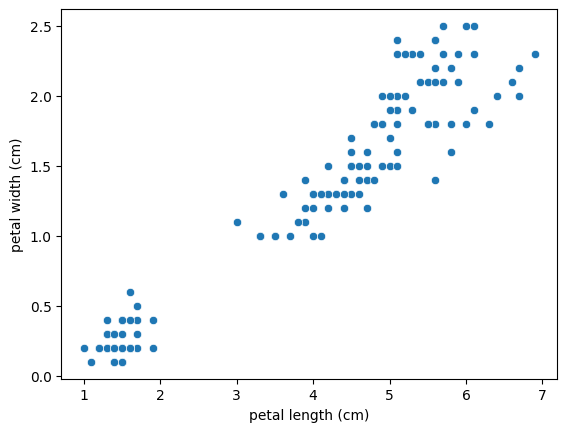

In [49]:
sns.scatterplot(x=df['petal length (cm)'],y=df["petal width (cm)"],data=df)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

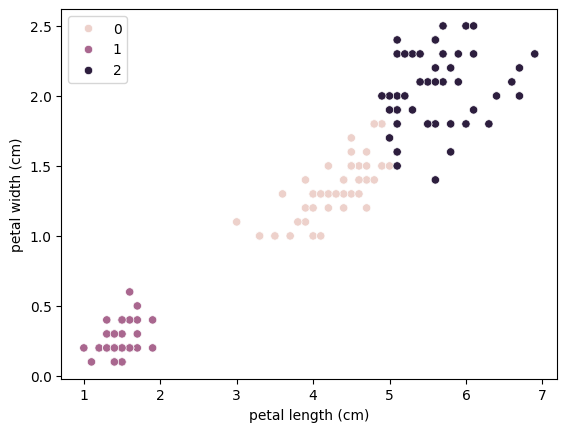

In [50]:
km=KMeans(n_clusters=3)
predicted_clusters=km.fit_predict(df[['petal length (cm)','petal width (cm)']])
cluster=predicted_clusters
sns.scatterplot(data=df,x='petal length (cm)',y='petal width (cm)',hue=cluster)

In [51]:
scaler=MinMaxScaler()
scaler.fit(df[['petal length (cm)']])
df['petal length']=scaler.transform(df[['petal length (cm)']])
df
scaler.fit(df[['petal width (cm)']])
df['petal width']=scaler.transform(df[['petal width (cm)']])
df


,petal length (cm),petal width (cm),petal length,petal width
0,1.4,0.2,0.067797,0.041667
1,1.4,0.2,0.067797,0.041667
2,1.3,0.2,0.050847,0.041667
3,1.5,0.2,0.084746,0.041667
4,1.4,0.2,0.067797,0.041667
...,...,...,...,...
145,5.2,2.3,0.711864,0.916667
146,5.0,1.9,0.677966,0.750000
147,5.2,2.0,0.711864,0.791667
148,5.4,2.3,0.745763,0.916667


<Axes: xlabel='petal length', ylabel='petal width'>

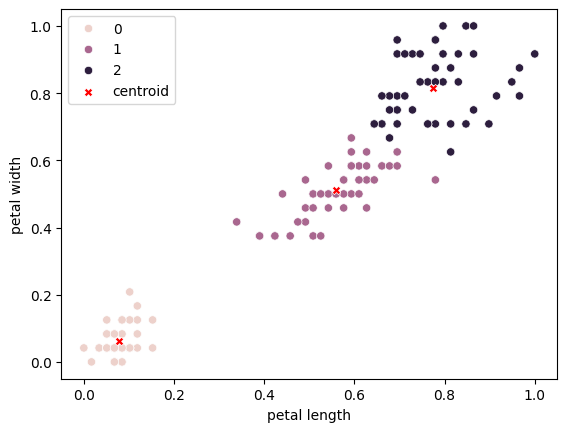

In [52]:
Cluster=km.fit_predict(df[['petal length','petal width']])
sns.scatterplot(data=df,x='petal length',y='petal width',hue=Cluster)
sns.scatterplot(x=km.cluster_centers_[:,0],y=km.cluster_centers_[:,1],color='red',label='centroid',marker='X')

FIND K USING ELBOW PLOT

In [53]:
k_range=range(1,10)
sse=[]

for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)','petal width (cm)']])
    sse.append(km.inertia_)

sse


[550.8953333333333,
 86.39021984551397,
 31.371358974358973,
 20.238882783882783,
 14.70111201079622,
 11.051428739411808,
 9.52657254246728,
 8.038420634920634,
 6.586036796536797]

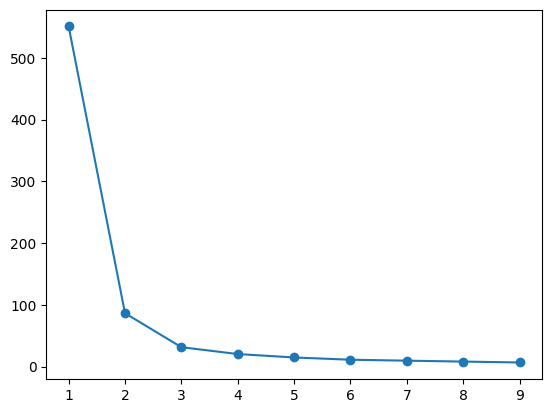

In [54]:
plt.plot(k_range,sse,marker='o')

K=3

In [55]:
## save the model
import joblib
joblib.dump(km,'iris_km_model')

## save the new dataset
df.to_csv('iris_flower.csv', index=False)